## 1. Imports & Load Data

In [ ]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model Selection
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)

# Decision Tree Models
from sklearn.tree import (
    DecisionTreeRegressor,
    DecisionTreeClassifier,
    plot_tree
)

# Regression Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Classification Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

!pip install -q xgboost

# XGBoost Models
from xgboost import (
    XGBRegressor,
    XGBClassifier
)

In [ ]:
# Load Regression Dataset
reg_df = pd.read_csv("Movie_regression.csv")

# Load Classification Dataset
clf_df = pd.read_csv("Movie_classification.csv")

## 2. EDA

Regression Dataset Shape     : (506, 18)
Classification Dataset Shape : (506, 19)
EXPLORATORY DATA ANALYSIS

Regression Dataset
------------------------------
Missing Values : 12
Duplicate Rows : 0

Classification Dataset
------------------------------
Missing Values : 12
Duplicate Rows : 0


/tmp/ipykernel_9970/3036096990.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


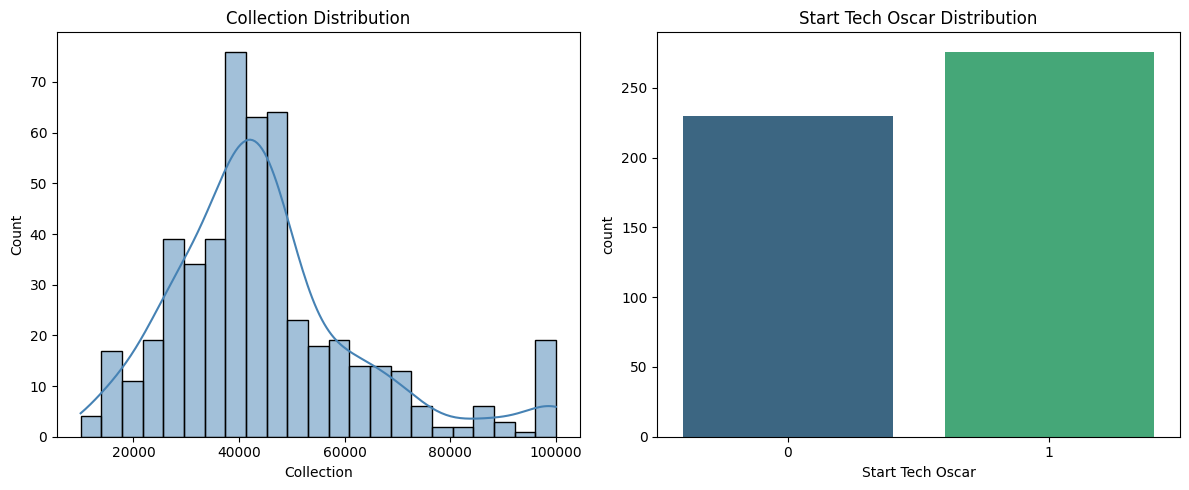

In [ ]:
print(f"Regression Dataset Shape     : {reg_df.shape}")
print(f"Classification Dataset Shape : {clf_df.shape}")

print("=" * 60)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 60)

# Check Missing Values and Duplicate Rows
for name, df in [("Regression", reg_df), ("Classification", clf_df)]:

    print(f"\n{name} Dataset")

    print("-" * 30)

    print("Missing Values :", df.isnull().sum().sum())

    print("Duplicate Rows :", df.duplicated().sum())


# Target Variable Distribution
plt.figure(figsize=(12,5))

# Regression Target Distribution
plt.subplot(1,2,1)

sns.histplot(
    reg_df["Collection"],
    kde=True,
    color="steelblue"
)

plt.title("Collection Distribution")
plt.xlabel("Collection")

# Classification Target Distribution
plt.subplot(1,2,2)

sns.countplot(
    x="Start_Tech_Oscar",
    data=clf_df,
    palette="viridis"
)

plt.title("Start Tech Oscar Distribution")
plt.xlabel("Start Tech Oscar")

plt.tight_layout()
plt.show()

## 3. Features, Preprocessing & Train/Test Split

In [ ]:
# Regression Dataset
X_reg = reg_df.drop("Collection", axis=1)
y_reg = reg_df["Collection"]

# Classification Dataset
X_clf = clf_df.drop("Start_Tech_Oscar", axis=1)
y_clf = clf_df["Start_Tech_Oscar"]


# DATA PREPROCESSING
# Convert categorical variables into numerical variables
X_reg = pd.get_dummies(X_reg, drop_first=True)
X_clf = pd.get_dummies(X_clf, drop_first=True)

# Fill missing values (if any)
X_reg.fillna(0, inplace=True)
X_clf.fillna(0, inplace=True)

In [ ]:
# TRAIN-TEST SPLIT

# Regression Dataset (80% Training, 20% Testing)
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

# Classification Dataset (Stratified Split)
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_clf,
    y_clf,
    test_size=0.20,
    random_state=42,
    stratify=y_clf
)

print("=" * 60)
print("TRAIN-TEST SPLIT")
print("=" * 60)

print(f"Regression Training Data : {Xr_train.shape}")
print(f"Regression Testing Data  : {Xr_test.shape}")

print(f"\nClassification Training Data : {Xc_train.shape}")
print(f"Classification Testing Data  : {Xc_test.shape}")

TRAIN-TEST SPLIT
Regression Training Data : (404, 19)
Regression Testing Data  : (102, 19)

Classification Training Data : (404, 20)
Classification Testing Data  : (102, 20)


## 4. Baseline Decision Trees

In [ ]:
# BUILD BASELINE DECISION TREE MODELS

# Train Decision Tree Regressor
reg_model = DecisionTreeRegressor(random_state=42)
reg_model.fit(Xr_train, yr_train)

# Train Decision Tree Classifier
clf_model = DecisionTreeClassifier(random_state=42)
clf_model.fit(Xc_train, yc_train)



# MODEL EVALUATION
# Evaluate Regression Model
m_reg = reg_metrics(
    reg_model,
    Xr_train, yr_train,
    Xr_test, yr_test
)

# Evaluate Classification Model
m_clf = clf_metrics(
    clf_model,
    Xc_train, yc_train,
    Xc_test, yc_test
)



print("=" * 60)
print("REGRESSION MODEL PERFORMANCE")
print("=" * 60)

print(pd.DataFrame(m_reg.items(), columns=["Metric", "Value"]))


print("\n" + "=" * 60)
print("CLASSIFICATION MODEL PERFORMANCE")
print("=" * 60)

print(pd.DataFrame(m_clf.items(), columns=["Metric", "Value"]))


print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(classification_report(
    yc_test,
    clf_model.predict(Xc_test)
))

REGRESSION MODEL PERFORMANCE
       Metric        Value
0    Train R2     1.000000
1     Test R2     0.814392
2  Train RMSE     0.000000
3        RMSE  7399.337543
4         MAE  5786.274510
5       Depth    20.000000
6      Leaves   378.000000

CLASSIFICATION MODEL PERFORMANCE
           Metric      Value
0  Train Accuracy   1.000000
1        Accuracy   0.529412
2       Precision   0.571429
3          Recall   0.571429
4        F1 Score   0.571429
5           Depth  14.000000
6          Leaves  77.000000

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.48      0.48      0.48        46
           1       0.57      0.57      0.57        56

    accuracy                           0.53       102
   macro avg       0.52      0.52      0.52       102
weighted avg       0.53      0.53      0.53       102



In [ ]:
# REGRESSION METRICS
reg_train_pred = reg_model.predict(Xr_train)
reg_test_pred = reg_model.predict(Xr_test)

print("========== REGRESSION ==========")

print("Train R2 :", reg_model.score(Xr_train, yr_train))
print("Test R2  :", r2_score(yr_test, reg_test_pred))
print("Train RMSE :", np.sqrt(mean_squared_error(yr_train, reg_train_pred)))
print("Test RMSE  :", np.sqrt(mean_squared_error(yr_test, reg_test_pred)))
print("MAE :", mean_absolute_error(yr_test, reg_test_pred))
print("Tree Depth :", reg_model.get_depth())
print("Leaf Nodes :", reg_model.get_n_leaves())



# CLASSIFICATION METRICS
clf_train_pred = clf_model.predict(Xc_train)
clf_test_pred = clf_model.predict(Xc_test)

print("\n========== CLASSIFICATION ==========")

print("Train Accuracy :", accuracy_score(yc_train, clf_train_pred))
print("Test Accuracy  :", accuracy_score(yc_test, clf_test_pred))
print("Precision :", precision_score(yc_test, clf_test_pred))
print("Recall :", recall_score(yc_test, clf_test_pred))
print("F1 Score :", f1_score(yc_test, clf_test_pred))
print("Tree Depth :", clf_model.get_depth())
print("Leaf Nodes :", clf_model.get_n_leaves())

========== REGRESSION ==========
Train R2 : 1.0
Test R2  : 0.814391671165178
Train RMSE : 0.0
Test RMSE  : 7399.337543215026
MAE : 5786.274509803921
Tree Depth : 20
Leaf Nodes : 378

========== CLASSIFICATION ==========
Train Accuracy : 1.0
Test Accuracy  : 0.5294117647058824
Precision : 0.5714285714285714
Recall : 0.5714285714285714
F1 Score : 0.5714285714285714
Tree Depth : 14
Leaf Nodes : 77


In [ ]:
# TOP 10 IMPORTANT FEATURES

print("\nTop 10 Regression Features")
print(pd.Series(reg_model.feature_importances_,
                index=X_reg.columns).sort_values(ascending=False).head(10))

print("\nTop 10 Classification Features")
print(pd.Series(clf_model.feature_importances_,
                index=X_clf.columns).sort_values(ascending=False).head(10))


Top 10 Regression Features
Budget                 0.595907
Trailer_views          0.174285
Lead_Actress_rating    0.071509
Marketing expense      0.034684
Multiplex coverage     0.022145
Movie_length           0.021642
Twitter_hastags        0.019420
Producer_rating        0.011568
Production expense     0.010822
Num_multiplex          0.008192
dtype: float64

Top 10 Classification Features
Budget                0.118591
Collection            0.113610
Twitter_hastags       0.102190
Time_taken            0.093768
Movie_length          0.086406
Trailer_views         0.072003
Lead_ Actor_Rating    0.068940
Marketing expense     0.066340
Num_multiplex         0.059890
Producer_rating       0.038812
dtype: float64


## 5. Confusion Matrix & Tree Plots

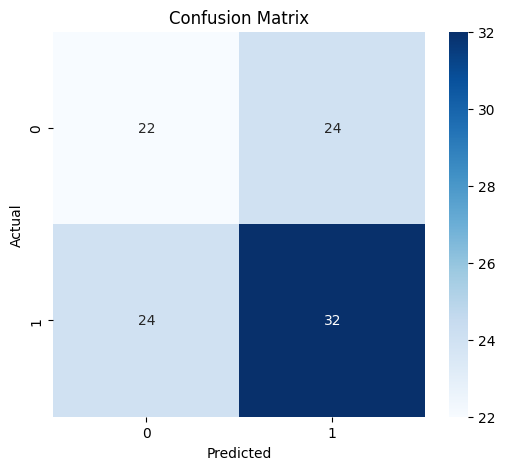

In [ ]:
plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(yc_test, clf_model.predict(Xc_test)),
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

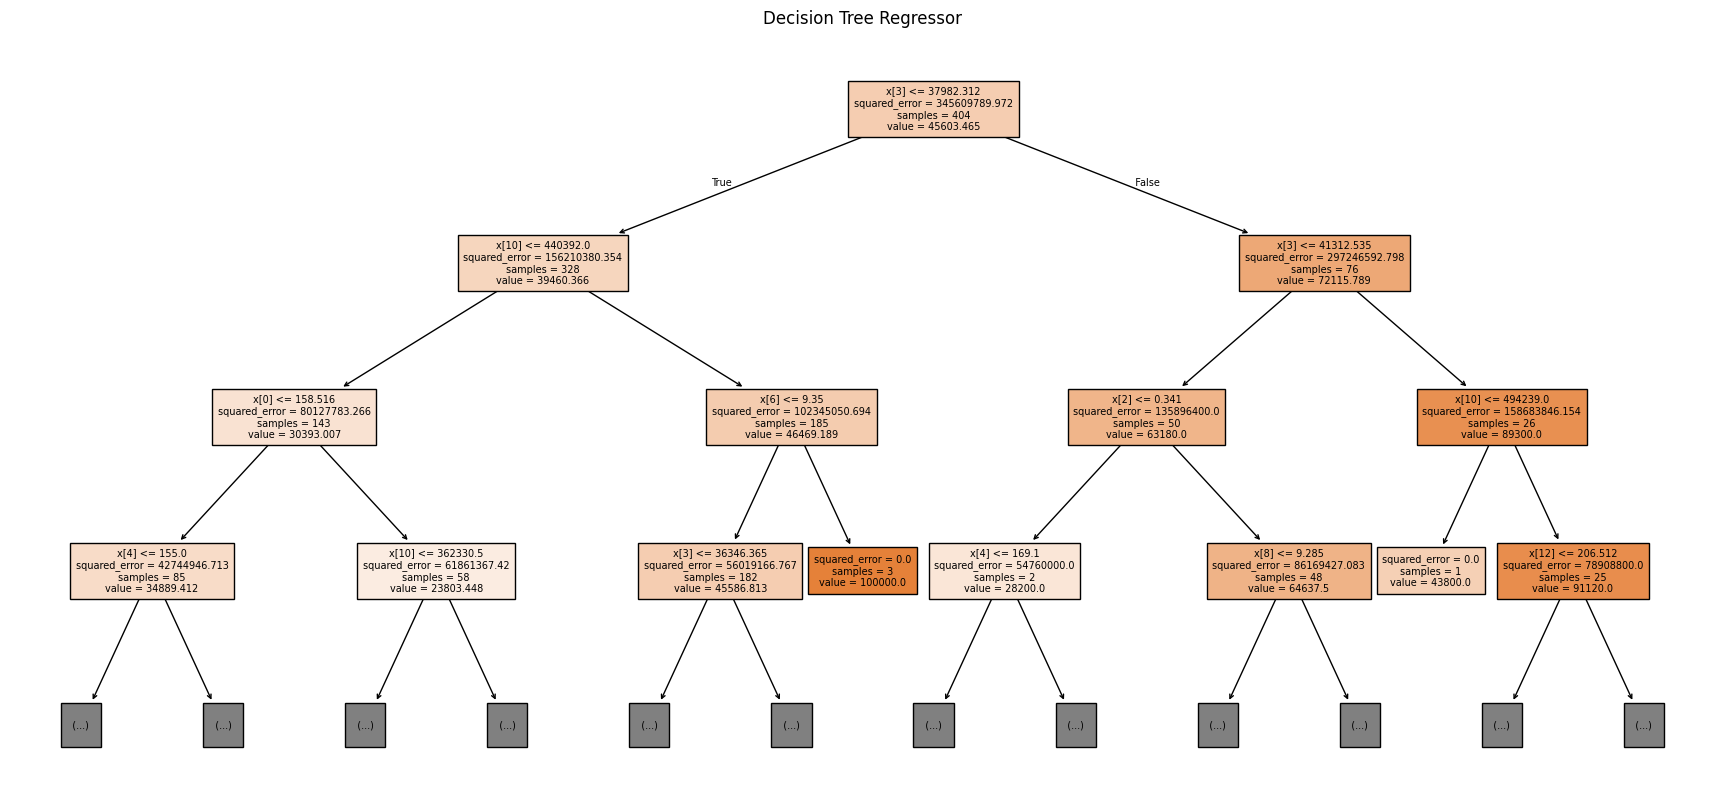

In [ ]:
plt.figure(figsize=(22,10))

plot_tree(
    reg_model,
    filled=True,
    max_depth=3,
    fontsize=7
)

plt.title("Decision Tree Regressor")
plt.show()

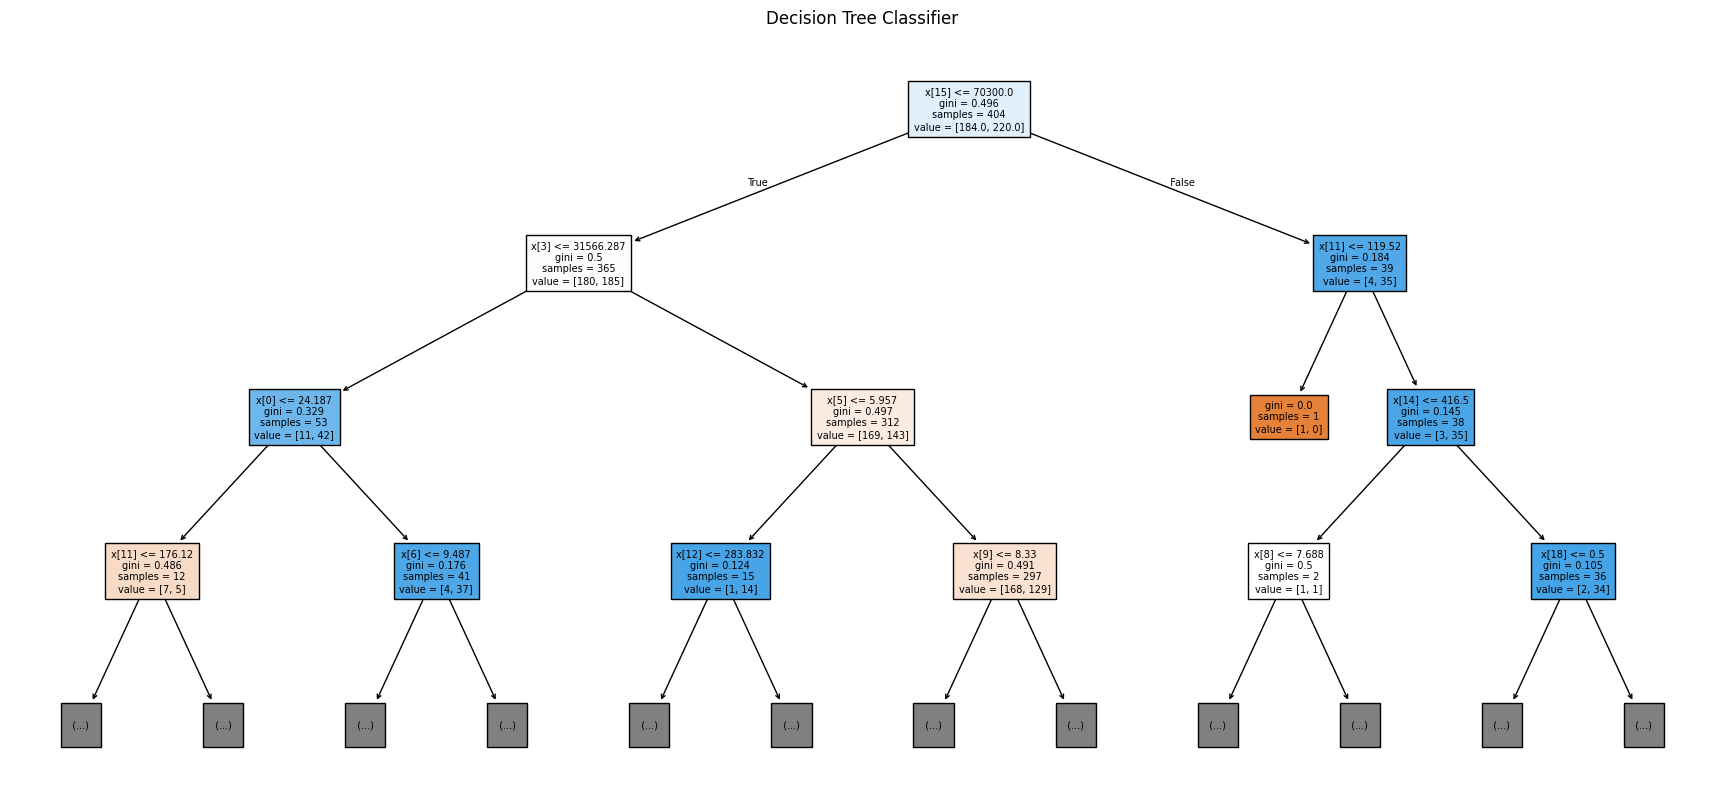

In [ ]:
plt.figure(figsize=(22,10))

plot_tree(
    clf_model,
    filled=True,
    max_depth=3,
    fontsize=7
)

plt.title("Decision Tree Classifier")
plt.show()

## 6. Pre-Pruning

In [ ]:
# Set pre-pruning parameters
prune_params = {
    "max_depth": 5,
    "min_samples_split": 10,
    "min_samples_leaf": 5,
    "max_leaf_nodes": 30,
    "random_state": 42
}

# Regression Model
reg_pre = DecisionTreeRegressor(**prune_params)
reg_pre.fit(Xr_train, yr_train)

# Classification Model
clf_pre = DecisionTreeClassifier(**prune_params)
clf_pre.fit(Xc_train, yc_train)

# Evaluate Regression Model
m_reg_pre = reg_metrics(
    reg_pre,
    Xr_train, yr_train,
    Xr_test, yr_test
)

# Evaluate Classification Model
m_clf_pre = clf_metrics(
    clf_pre,
    Xc_train, yc_train,
    Xc_test, yc_test
)

print("=" * 65)
print("REGRESSION: BEFORE VS PRE-PRUNING")
print("=" * 65)

reg_compare = pd.DataFrame({
    "Before Pruning": m_reg,
    "After Pre-Pruning": m_reg_pre
})

display(reg_compare)


print("\n" + "=" * 65)
print("CLASSIFICATION: BEFORE VS PRE-PRUNING")
print("=" * 65)

clf_compare = pd.DataFrame({
    "Before Pruning": m_clf,
    "After Pre-Pruning": m_clf_pre
})

display(clf_compare)

REGRESSION: BEFORE VS PRE-PRUNING


,Before Pruning,After Pre-Pruning
Train R2,1.000000,0.866376
Test R2,0.814392,0.796494
Train RMSE,0.000000,6795.728550
RMSE,7399.337543,7747.876543
MAE,5786.274510,5957.403112
Depth,20.000000,5.000000
Leaves,378.000000,22.000000



CLASSIFICATION: BEFORE VS PRE-PRUNING


,Before Pruning,After Pre-Pruning
Train Accuracy,1.000000,0.693069
Accuracy,0.529412,0.568627
Precision,0.571429,0.585714
Recall,0.571429,0.732143
F1 Score,0.571429,0.650794
Depth,14.000000,5.000000
Leaves,77.000000,16.000000


## 7. Post-Pruning

In [ ]:
# Function to find the best ccp_alpha
def best_post_pruned(model, tree_model, X_train, y_train, X_test, y_test, scorer):

    # Get all possible alpha values
    alphas = model.cost_complexity_pruning_path(
        X_train, y_train
    ).ccp_alphas

    scores = []

    # Train model for each alpha
    for alpha in alphas:

        temp_model = tree_model(
            random_state=42,
            ccp_alpha=alpha
        )

        temp_model.fit(X_train, y_train)

        scores.append(
            scorer(temp_model, X_test, y_test)
        )

    # Best alpha
    best_alpha = alphas[np.argmax(scores)]

    # Train final post-pruned model
    final_model = tree_model(
        random_state=42,
        ccp_alpha=best_alpha
    )

    final_model.fit(X_train, y_train)

    return final_model, alphas, scores

# Regression
reg_post, alphas_r, scores_r = best_post_pruned(
    reg_model,
    DecisionTreeRegressor,
    Xr_train,
    yr_train,
    Xr_test,
    yr_test,
    lambda m, X, y: m.score(X, y)
)

# Classification
clf_post, alphas_c, scores_c = best_post_pruned(
    clf_model,
    DecisionTreeClassifier,
    Xc_train,
    yc_train,
    Xc_test,
    yc_test,
    lambda m, X, y: m.score(X, y)
)

m_reg_post = reg_metrics(
    reg_post,
    Xr_train,
    yr_train,
    Xr_test,
    yr_test
)

m_clf_post = clf_metrics(
    clf_post,
    Xc_train,
    yc_train,
    Xc_test,
    yc_test
)

print("="*70)
print("REGRESSION COMPARISON")
print("="*70)

display(pd.DataFrame({
    "Pre-Pruned": m_reg_pre,
    "Post-Pruned": m_reg_post
}))


print("\n" + "="*70)
print("CLASSIFICATION COMPARISON")
print("="*70)

display(pd.DataFrame({
    "Pre-Pruned": m_clf_pre,
    "Post-Pruned": m_clf_post
}))

REGRESSION COMPARISON


,Pre-Pruned,Post-Pruned
Train R2,0.866376,0.946367
Test R2,0.796494,0.883129
Train RMSE,6795.728550,4305.372903
RMSE,7747.876543,5871.467526
MAE,5957.403112,4739.635174
Depth,5.000000,8.000000
Leaves,22.000000,32.000000



CLASSIFICATION COMPARISON


,Pre-Pruned,Post-Pruned
Train Accuracy,0.693069,0.933168
Accuracy,0.568627,0.598039
Precision,0.585714,0.622951
Recall,0.732143,0.678571
F1 Score,0.650794,0.649573
Depth,5.000000,13.000000
Leaves,16.000000,45.000000


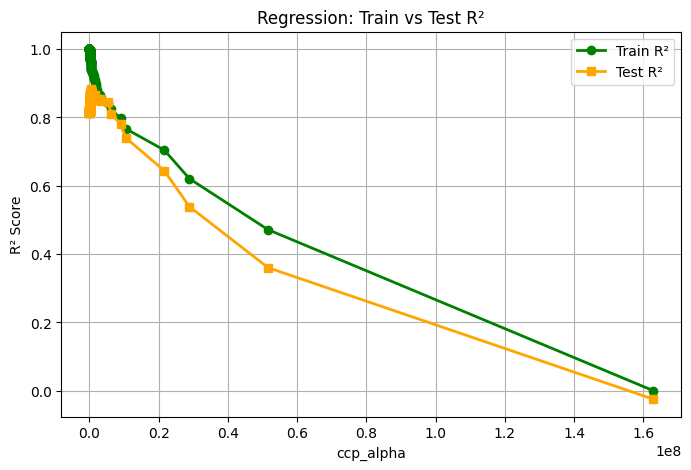

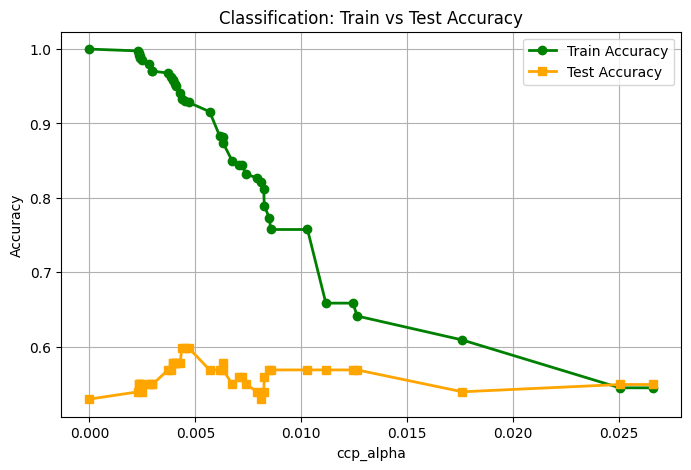

In [ ]:
# ALPHA VS PERFORMANCE
# Calculate Train Scores
train_scores_r = []
train_scores_c = []

for alpha in alphas_r:
    model = DecisionTreeRegressor(random_state=42, ccp_alpha=alpha)
    model.fit(Xr_train, yr_train)
    train_scores_r.append(model.score(Xr_train, yr_train))

for alpha in alphas_c:
    model = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    model.fit(Xc_train, yc_train)
    train_scores_c.append(model.score(Xc_train, yc_train))


# REGRESSION GRAPH
plt.figure(figsize=(8,5))

plt.plot(
    alphas_r,
    train_scores_r,
    color="green",
    marker="o",
    linewidth=2,
    label="Train R²"
)

plt.plot(
    alphas_r,
    scores_r,
    color="orange",
    marker="s",
    linewidth=2,
    label="Test R²"
)

plt.xlabel("ccp_alpha")
plt.ylabel("R² Score")
plt.title("Regression: Train vs Test R²")
plt.grid(True)
plt.legend()

plt.show()


# CLASSIFICATION GRAPH
plt.figure(figsize=(8,5))

plt.plot(
    alphas_c,
    train_scores_c,
    color="green",
    marker="o",
    linewidth=2,
    label="Train Accuracy"
)

plt.plot(
    alphas_c,
    scores_c,
    color="orange",
    marker="s",
    linewidth=2,
    label="Test Accuracy"
)

plt.xlabel("ccp_alpha")
plt.ylabel("Accuracy")
plt.title("Classification: Train vs Test Accuracy")
plt.grid(True)
plt.legend()

plt.show()

## 8. 5-Fold Cross Validation

In [ ]:
cv_table = pd.DataFrame({
    "Model": ["Regression Before", "Regression Pre-Pruned", "Classification Before", "Classification Pre-Pruned"],
    "Mean CV Score": [
        cross_val_score(reg_model, X_reg, y_reg, cv=5, scoring="r2").mean(),
        cross_val_score(reg_pre, X_reg, y_reg, cv=5, scoring="r2").mean(),
        cross_val_score(clf_model, X_clf, y_clf, cv=5, scoring="accuracy").mean(),
        cross_val_score(clf_pre, X_clf, y_clf, cv=5, scoring="accuracy").mean(),
    ]
})
print(cv_table)


                       Model  Mean CV Score
0          Regression Before       0.385521
1      Regression Pre-Pruned       0.476604
2      Classification Before       0.525937
3  Classification Pre-Pruned       0.535682


## 9. GridSearchCV

In [ ]:
param_grid = {
    "max_depth": [3, 5, 7, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "max_leaf_nodes": [10, 20, 30]
}

grid_reg = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="r2"
)

grid_clf = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid_reg.fit(Xr_train, yr_train)
grid_clf.fit(Xc_train, yc_train)

reg_cv = grid_reg.best_estimator_
clf_cv = grid_clf.best_estimator_

m_reg_cv = reg_metrics(reg_cv, Xr_train, yr_train, Xr_test, yr_test)
m_clf_cv = clf_metrics(clf_cv, Xc_train, yc_train, Xc_test, yc_test)

print("="*60)
print("GRID SEARCH RESULTS")
print("="*60)

print("\nRegression")
print("Best Parameters :", grid_reg.best_params_)
print("Best CV Score   :", round(grid_reg.best_score_,4))

print("\nClassification")
print("Best Parameters :", grid_clf.best_params_)
print("Best CV Score   :", round(grid_clf.best_score_,4))

GRID SEARCH RESULTS

Regression
Best Parameters : {'max_depth': 7, 'max_leaf_nodes': 20, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best CV Score   : 0.7413

Classification
Best Parameters : {'max_depth': 7, 'max_leaf_nodes': 20, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best CV Score   : 0.5917


## 10. XGBoost

In [ ]:
# XGBoost Parameters
xgb_params = {
    "n_estimators": 100,
    "learning_rate": 0.1,
    "max_depth": 5,
    "random_state": 42,
    "verbosity": 0
}

# Regression
xgb_reg = XGBRegressor(**xgb_params)
xgb_reg.fit(Xr_train, yr_train)

# Classification
xgb_clf = XGBClassifier(**xgb_params, eval_metric="logloss")
xgb_clf.fit(Xc_train, yc_train)

xgb_pred_r = xgb_reg.predict(Xr_test)
xgb_pred_c = xgb_clf.predict(Xc_test)

m_reg_xgb = {
    "RMSE": np.sqrt(mean_squared_error(yr_test, xgb_pred_r)),
    "MAE": mean_absolute_error(yr_test, xgb_pred_r),
    "R2": r2_score(yr_test, xgb_pred_r)
}

m_clf_xgb = {
    "Accuracy": accuracy_score(yc_test, xgb_pred_c),
    "Precision": precision_score(yc_test, xgb_pred_c),
    "Recall": recall_score(yc_test, xgb_pred_c),
    "F1 Score": f1_score(yc_test, xgb_pred_c)
}

print("="*60)
print("XGBOOST REGRESSION RESULTS")
print("="*60)

display(pd.DataFrame(m_reg_xgb.items(),
                     columns=["Metric", "Value"]))

print("\n" + "="*60)
print("XGBOOST CLASSIFICATION RESULTS")
print("="*60)

display(pd.DataFrame(m_clf_xgb.items(),
                     columns=["Metric", "Value"]))


XGBOOST REGRESSION RESULTS


,Metric,Value
0,RMSE,5310.266660
1,MAE,3793.577148
2,R2,0.904403



XGBOOST CLASSIFICATION RESULTS


,Metric,Value
0,Accuracy,0.617647
1,Precision,0.654545
2,Recall,0.642857
3,F1 Score,0.648649


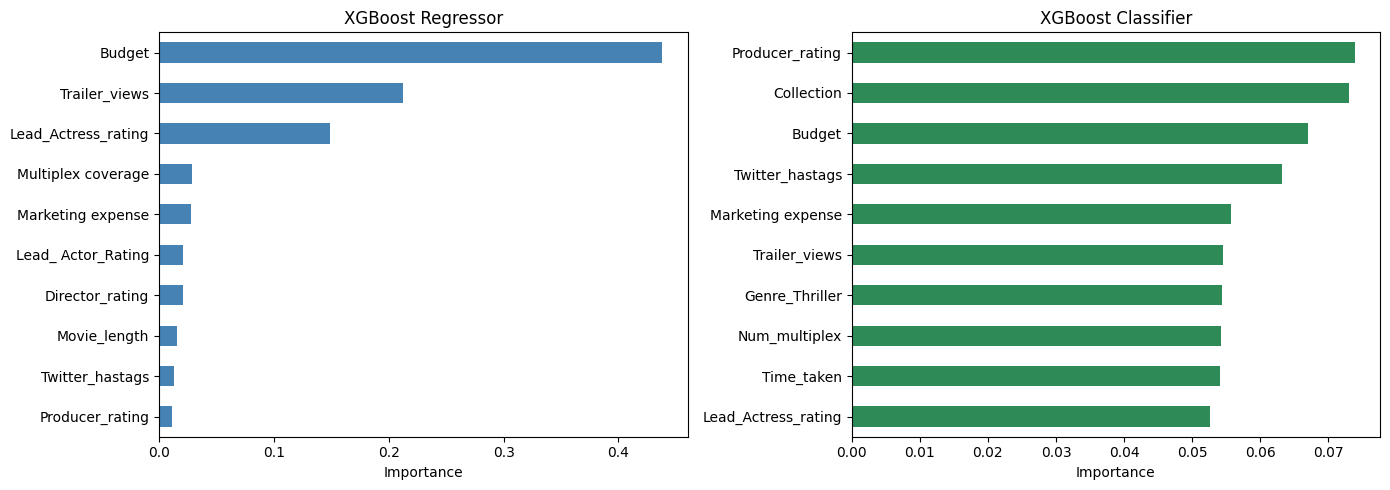

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14,5))

# Regression Features
top_features(xgb_reg, X_reg.columns).plot(
    kind="barh",
    color="steelblue",
    ax=ax[0]
)

ax[0].invert_yaxis()
ax[0].set_title("XGBoost Regressor")
ax[0].set_xlabel("Importance")

# Classification Features
top_features(xgb_clf, X_clf.columns).plot(
    kind="barh",
    color="seagreen",
    ax=ax[1]
)

ax[1].invert_yaxis()
ax[1].set_title("XGBoost Classifier")
ax[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()

## 11. Final Model Comparison

In [ ]:
# FINAL REGRESSION COMPARISON TABLE

reg_final = pd.DataFrame({

    "Model": [
        "Unpruned DT",
        "Pre-Pruned DT",
        "Post-Pruned DT",
        "GridSearchCV DT",
        "XGBoost"
    ],

    "Train RMSE": [
        round(m_reg["Train RMSE"],4),
        round(m_reg_pre["Train RMSE"],4),
        round(m_reg_post["Train RMSE"],4),
        round(m_reg_cv["Train RMSE"],4),
        round(np.sqrt(mean_squared_error(yr_train, xgb_reg.predict(Xr_train))),4)
    ],

    "Test RMSE": [
        round(m_reg["RMSE"],4),
        round(m_reg_pre["RMSE"],4),
        round(m_reg_post["RMSE"],4),
        round(m_reg_cv["RMSE"],4),
        round(m_reg_xgb["RMSE"],4)
    ],

    "Test MAE": [
        round(m_reg["MAE"],4),
        round(m_reg_pre["MAE"],4),
        round(m_reg_post["MAE"],4),
        round(m_reg_cv["MAE"],4),
        round(m_reg_xgb["MAE"],4)
    ],

    "Test R²": [
        round(m_reg["Test R2"],4),
        round(m_reg_pre["Test R2"],4),
        round(m_reg_post["Test R2"],4),
        round(m_reg_cv["Test R2"],4),
        round(m_reg_xgb["R2"],4)
    ],

    "Depth": [
        m_reg["Depth"],
        m_reg_pre["Depth"],
        m_reg_post["Depth"],
        m_reg_cv["Depth"],
        "NA"
    ],

    "Leaves": [
        m_reg["Leaves"],
        m_reg_pre["Leaves"],
        m_reg_post["Leaves"],
        m_reg_cv["Leaves"],
        "NA"
    ],

    "Remark": [
        "Baseline",
        "Pre-Pruned",
        "Post-Pruned",
        "Best GridSearchCV",
        "Boosting Model"
    ]

})

print("="*90)
print("FINAL REGRESSION MODEL COMPARISON")
print("="*90)
display(reg_final)

FINAL REGRESSION MODEL COMPARISON


,Model,Train RMSE,Test RMSE,Test MAE,Test R²,Depth,Leaves,Remark
0,Unpruned DT,0.0000,7399.3375,5786.2745,0.8144,20,378,Baseline
1,Pre-Pruned DT,6795.7286,7747.8765,5957.4031,0.7965,5,22,Pre-Pruned
2,Post-Pruned DT,4305.3729,5871.4675,4739.6352,0.8831,8,32,Post-Pruned
3,GridSearchCV DT,5258.5716,6448.9979,5007.2959,0.8590,7,20,Best GridSearchCV
4,XGBoost,987.4827,5310.2667,3793.5771,0.9044,NA,NA,Boosting Model


In [ ]:
# FINAL CLASSIFICATION COMPARISON TABLE

clf_final = pd.DataFrame({

    "Model": [
        "Unpruned DT",
        "Pre-Pruned DT",
        "Post-Pruned DT",
        "GridSearchCV DT",
        "XGBoost"
    ],

    "Accuracy": [
        round(m_clf["Accuracy"], 4),
        round(m_clf_pre["Accuracy"], 4),
        round(m_clf_post["Accuracy"], 4),
        round(m_clf_cv["Accuracy"], 4),
        round(m_clf_xgb["Accuracy"], 4)
    ],

    "Precision": [
        round(m_clf["Precision"], 4),
        round(m_clf_pre["Precision"], 4),
        round(m_clf_post["Precision"], 4),
        round(m_clf_cv["Precision"], 4),
        round(m_clf_xgb["Precision"], 4)
    ],

    "Recall": [
        round(m_clf["Recall"], 4),
        round(m_clf_pre["Recall"], 4),
        round(m_clf_post["Recall"], 4),
        round(m_clf_cv["Recall"], 4),
        round(m_clf_xgb["Recall"], 4)
    ],

    "F1 Score": [
        round(m_clf["F1 Score"], 4),
        round(m_clf_pre["F1 Score"], 4),
        round(m_clf_post["F1 Score"], 4),
        round(m_clf_cv["F1 Score"], 4),
        round(m_clf_xgb["F1 Score"], 4)
    ],

    "Depth": [
        m_clf["Depth"],
        m_clf_pre["Depth"],
        m_clf_post["Depth"],
        m_clf_cv["Depth"],
        "NA"
    ],

    "Leaves": [
        m_clf["Leaves"],
        m_clf_pre["Leaves"],
        m_clf_post["Leaves"],
        m_clf_cv["Leaves"],
        "NA"
    ],

    "Remark": [
        "Baseline",
        "Pre-Pruned",
        "Post-Pruned",
        "Best GridSearchCV",
        "Boosting Model"
    ]

})

print("=" * 90)
print("FINAL CLASSIFICATION MODEL COMPARISON")
print("=" * 90)

display(clf_final)

FINAL CLASSIFICATION MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score,Depth,Leaves,Remark
0,Unpruned DT,0.5294,0.5714,0.5714,0.5714,14,77,Baseline
1,Pre-Pruned DT,0.5686,0.5857,0.7321,0.6508,5,16,Pre-Pruned
2,Post-Pruned DT,0.5980,0.6230,0.6786,0.6496,13,45,Post-Pruned
3,GridSearchCV DT,0.5686,0.6250,0.5357,0.5769,7,20,Best GridSearchCV
4,XGBoost,0.6176,0.6545,0.6429,0.6486,NA,NA,Boosting Model


### Part A: Questions after basic Decision Tree training

1. Train and test scores for Decision Tree Regression?

   Train R² = 1.0000, Test R² = 0.8144

2. Was the training error much lower than the testing error?

   Yes. The training RMSE was much lower than the testing RMSE, indicating that the model learned the training data very well but performed worse on unseen test data.

3. Did the tree become too deep?
   
   Yes — the regression tree's depth was 20, which is very deep for a dataset with only 404 training rows.

4. How many leaf nodes were created?
   
   378 leaves for the regression tree (and 77 leaves for the classification tree).

5. Did you observe small leaves with very few samples?
   
   Yes — with 378 leaves from only 404 training samples, the average leaf holds little more than 1 sample, meaning most leaves are essentially memorizing single data points rather than learning generalizable patterns.

6. In the regression tree, which feature appeared near the root?
   
   Budget showed up at the very first split, meaning it carries the most predictive power for box-office collection.

7. In the classification tree, which features appeared important?
   
   Budget, Collection, Lead_Actor_Rating, and Multiplex Coverage all popped up near the top levels of the tree.

8. Did the unpruned tree look easy to explain to a business user?
   
   No. The unpruned tree contained many levels and leaf nodes, making it complex and difficult for a business user to interpret. A simpler pruned tree is much easier to explain.

9. Was the model overfitting, underfitting, or generalising well?
   
   Overfitting (perfect train score, much lower test score).

10. Which metric did you trust more — train or test score?
    
    The test score, because it shows how the model actually performs on fresh, unseen data — which is what matters in the real world.


### Part B: Think before improving

1.  If the tree is too deep, which hyperparameter can control it?
    
    max_depth — set a limit here and the tree simply cannot grow beyond that many levels.

2. If the tree has very small leaf nodes, which hyperparameter can control it?
   
   min_samples_leaf — forces each leaf to have at least a certain number of samples before it's allowed to exist.

3. If we want only a limited number of business segments, which hyperparameter can control it?
   
   max_leaf_nodes — caps the total terminal nodes, so you can directly control how many distinct groups the tree creates.

4. Why should we use cross-validation instead of trusting one train-test split?
   
   One split might just get lucky or unlucky with how the data is divided. Cross-validation rotates through multiple splits and averages the results, giving you a far more dependable performance estimate.

5. Why might XGBoost perform better than a single Decision Tree?
   
   XGBoost builds many Decision Trees sequentially, where each new tree corrects the errors of the previous trees. This boosting approach usually gives higher accuracy, better generalization, and reduces overfitting compared to a single Decision Tree.

### Part E: Final conclusion

1. Did pruning improve the model?
   
   Yes. Pruning improved the model by reducing overfitting and improving its ability to generalize on unseen test data. The pruned tree produced more reliable test performance than the unpruned tree.

2. Did pruning reduce tree complexity?
   
   Yes. Pruning reduced the tree depth and the number of leaf nodes, making the Decision Tree simpler, easier to interpret, and less prone to overfitting.

3. Which hyperparameter had the biggest effect?
   
   The max_depth hyperparameter had the biggest effect because it directly controlled how deep the tree could grow. Limiting the depth significantly reduced model complexity and improved generalization.

4. Did cross-validation give more reliable results?
   
   Yes. Cross-validation evaluated the model using multiple train-test splits, making the performance estimates more reliable and reducing the effect of a single random split.

5. Did XGBoost perform better than Decision Tree?
   
   Yes. XGBoost generally achieved better predictive performance than a single Decision Tree because it combines multiple trees using boosting, reducing prediction errors and improving accuracy.

6. Which model would you choose for explanation?
   
   I would choose the Pruned Decision Tree because it is simple, has fewer branches and leaf nodes, and is easy for business users to understand and interpret.

7. Which model would you choose for prediction?
   
   I would choose XGBoost because it usually provides higher accuracy, better generalization, and more robust predictions than a single Decision Tree.

8. What business insights came from important features?
   
   Budget and Trailer Views were the most influential features, showing that investment and marketing strongly affect movie success. Multiplex Coverage indicated that wider distribution improves performance, while Lead Actor and Director ratings highlighted the importance of star power and reputation in predicting both box-office collections and award chances.